# Quantitative Analysis of Clinical Staging Ambiguity in Chronic Kidney Disease (CKD)

In [1]:
# Import libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Load Dataset

In [36]:
path = kagglehub.dataset_download("priyankabarik/chronic-kidney-disease-ckd-clinical-dataset")
# Directly load train and test CSV files
train_df = pd.read_csv(os.path.join(path, "Training_CKD_dataset.csv"))
test_df = pd.read_csv(os.path.join(path, "Testing_CKD_dataset.csv"))

# Dataset Overview

In [4]:
train_df.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No


## 1} Training Dataset Analysis

## Statistical Summary
### Training Dataset

In [5]:
train_df.describe()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,51.951905,0.500619,25.977571,113.497619,75.280857,84.280714,0.629571,21.682048,91.426095,59.986905,...,7493.323000,300422.551571,42.167238,134.330524,99.473762,6.998247,214.411762,199.511571,3.598048,6.507856
std,18.796090,0.500012,4.890439,19.151820,12.106952,14.387748,1.482399,20.800122,26.787045,136.148540,...,2019.807219,86546.236256,5.496877,37.623833,17.300907,1.736593,37.451581,58.167742,0.764034,0.865395
min,20.000000,0.000000,18.000000,90.000000,60.000000,60.000000,0.000000,7.000000,5.000000,0.000000,...,4000.000000,150022.000000,20.000000,70.000000,70.000000,4.000855,150.000000,100.000000,1.000000,5.000065
25%,36.000000,0.000000,22.000000,99.000000,66.000000,72.000000,0.000000,11.000000,89.000000,6.000000,...,5738.000000,225571.000000,40.000000,102.000000,84.000000,5.509804,182.000000,149.000000,3.000000,5.757357
50%,52.000000,1.000000,26.000000,110.000000,73.000000,84.000000,0.000000,15.000000,99.000000,13.000000,...,7504.000000,300718.000000,43.000000,134.000000,99.000000,7.002234,214.000000,199.000000,4.000000,6.520847
75%,68.000000,1.000000,30.000000,120.000000,80.000000,97.000000,1.000000,20.000000,109.000000,20.000000,...,9234.000000,375397.250000,46.000000,167.000000,114.000000,8.501457,247.000000,250.000000,4.000000,7.254656
max,84.000000,1.000000,34.000000,189.000000,119.000000,109.000000,9.000000,149.000000,119.000000,999.000000,...,10999.000000,449942.000000,49.000000,199.000000,129.000000,9.999904,279.000000,299.000000,4.000000,7.999568


## Check Dataset Structure to know
- number of rows
- number of columns
- datatype of each column
- missing values

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium

### Basic insights
- Record size 36 column & 21000 rows.
- Categorical column (5) - 'Target', 'Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney'.
- Numerical column (31) -  'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio', 'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium', 'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count', 'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume', 'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol', 'Triglycerides', 'Serum_Albumin', 'Total_Protein'.
- The dataset contains zero null values, indicating that there are no missing entries and the data is complete for analysis.



In [7]:
df=train_df

# Univariate Analysis

Pie chart of Target column

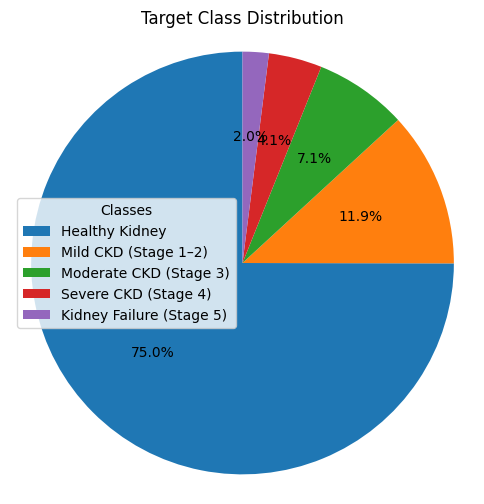

Target
Healthy Kidney              15744
Mild CKD (Stage 1–2)         2491
Moderate CKD (Stage 3)       1489
Severe CKD (Stage 4)          856
Kidney Failure (Stage 5)      420
Name: count, dtype: int64


In [8]:
counts = train_df['Target'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, autopct='%1.1f%%', startangle=90)
plt.title("Target Class Distribution")
plt.axis('equal')
plt.legend(counts.index, title="Classes", loc="best")
plt.show()
counts = train_df['Target'].value_counts()
print(counts)

## Insight
- This tells you that any machine learning model you build later will be very good at predicting "Healthy" but might struggle with "Stage 5" unless you balance the data later.

# Bivariate Analysis

## Q 1} Dose Age affect the Kidney Health?

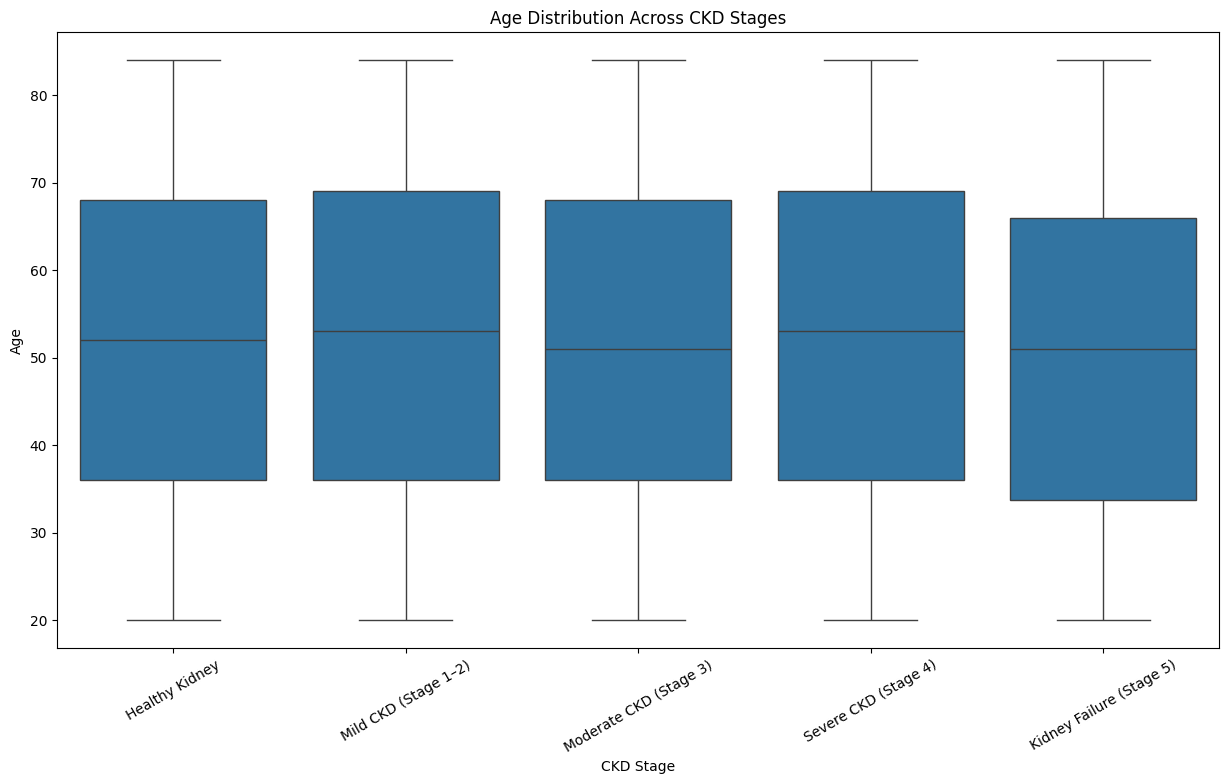

In [9]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Target',y='Age',data=df,order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Age")
plt.title("Age Distribution Across CKD Stages")
plt.xticks(rotation=30)
plt.show()

### As box plot shows:
- Similar average CKD stage across all age groups
- No clear increasing or decreasing trend
- Large overlap of ages in every CKD stage
- **Age has a minimal or weak impact on kidney disease prediction in this dataset compared to biochemical markers.**

## Q 2} Dose Family History of Kidney Disease affect the Kidney Health?

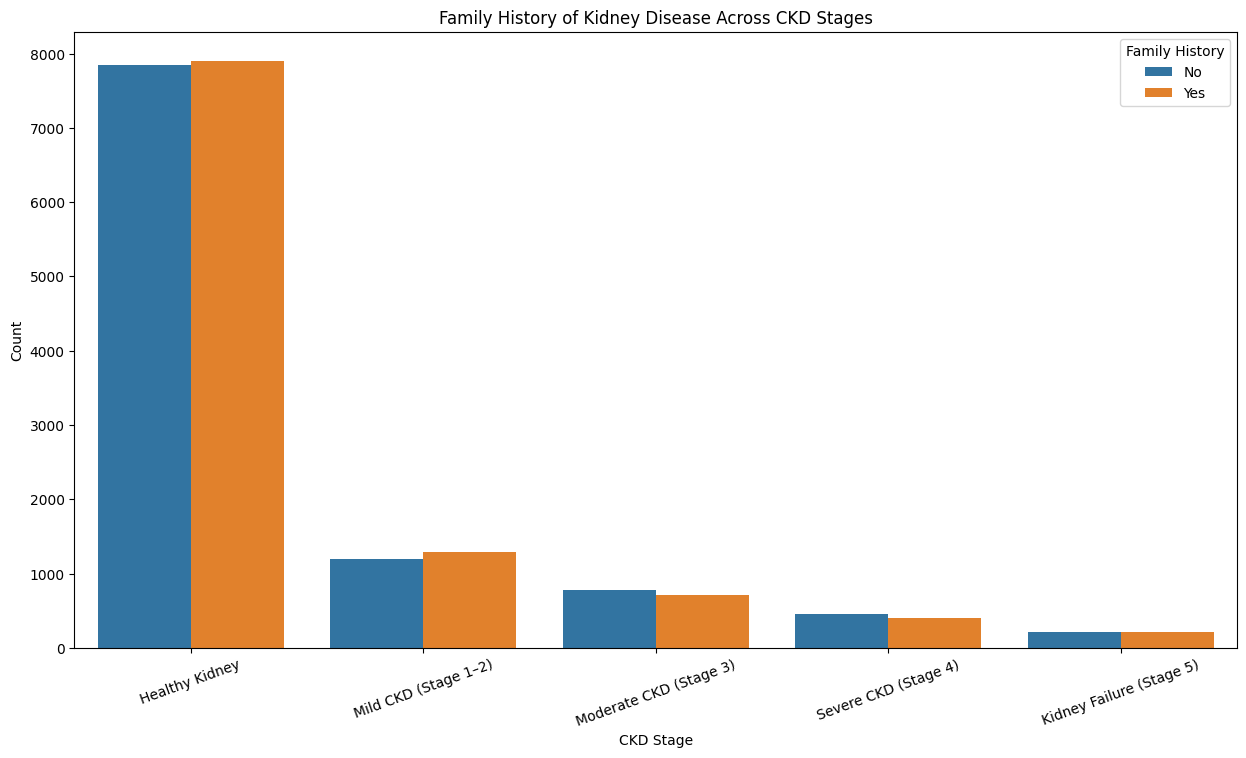

In [10]:
plt.figure(figsize=(15,8))
sns.countplot(x='Target',hue='Family_History_Kidney',data=df,order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"],hue_order=['No', 'Yes'])
plt.xlabel("CKD Stage")
plt.ylabel("Count")
plt.title("Family History of Kidney Disease Across CKD Stages")
plt.xticks(rotation=20)
plt.legend(title="Family History", loc='upper right')

plt.show()

### As the Count Plot Shows:
- A patient's family history does not have a significant impact on kidney health.

## Q 3} What is the impact of Estimated Glomerular Filtration Rate (eGFR) on Kidney Health?

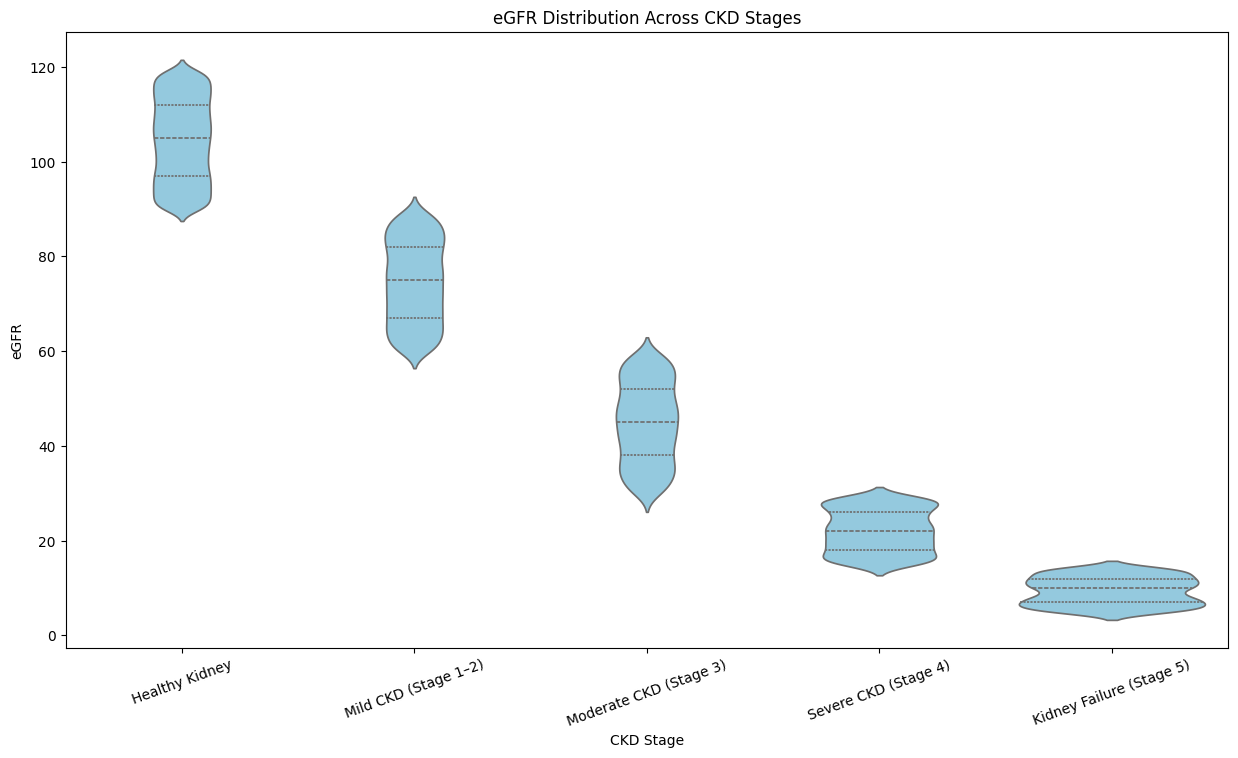

--- Actual eGFR Ranges per Stage in Dataset ---
                          Min eGFR  Max eGFR  Average eGFR
Target                                                    
Healthy Kidney                  90       119        104.47
Mild CKD (Stage 1–2)            60        89         74.51
Moderate CKD (Stage 3)          30        59         44.80
Severe CKD (Stage 4)            15        29         22.07
Kidney Failure (Stage 5)         5        14          9.43


In [11]:
plt.figure(figsize=(15,8))

sns.violinplot(x='Target',y='eGFR',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("eGFR")
plt.title("eGFR Distribution Across CKD Stages")
plt.xticks(rotation=20)

plt.show()

target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

egfr_ranges = df.groupby('Target')['eGFR'].agg(['min', 'max', 'mean']).reindex(target_order)
egfr_ranges.columns = ['Min eGFR', 'Max eGFR', 'Average eGFR']
print("--- Actual eGFR Ranges per Stage in Dataset ---")
print(egfr_ranges.round(2))

for i in range(len(egfr_ranges)-1):
    current_max = egfr_ranges.iloc[i]['Max eGFR']
    next_min = egfr_ranges.iloc[i+1]['Min eGFR']


### **eGFR Distribution Across CKD Stages**
* **Healthy Kidney:** High eGFR values (typically 90–119), reflecting normal, efficient blood filtration capacity.
* **Mild CKD (Stage 1–2):** Values drop to roughly 60–89, indicating the early onset of reduced filtration efficiency.
* **Moderate CKD (Stage 3):** Further decline to 30–59, marking a significant and progressive loss of kidney function.
* **Severe CKD (Stage 4):** Levels fall into the 15–29 range, representing severely impaired kidney filtration.
* **Kidney Failure (Stage 5):** Lowest values (typically below 14), indicating end-stage renal failure and the total loss of filtration ability.
* **Overall:** eGFR shows a perfect, steady downward trend across stages; as the primary metric used to define CKD, it provides the most precise separation between the stages for modeling.

## Q 4} What is the impact of Serum Creatinine on Kidney Health?

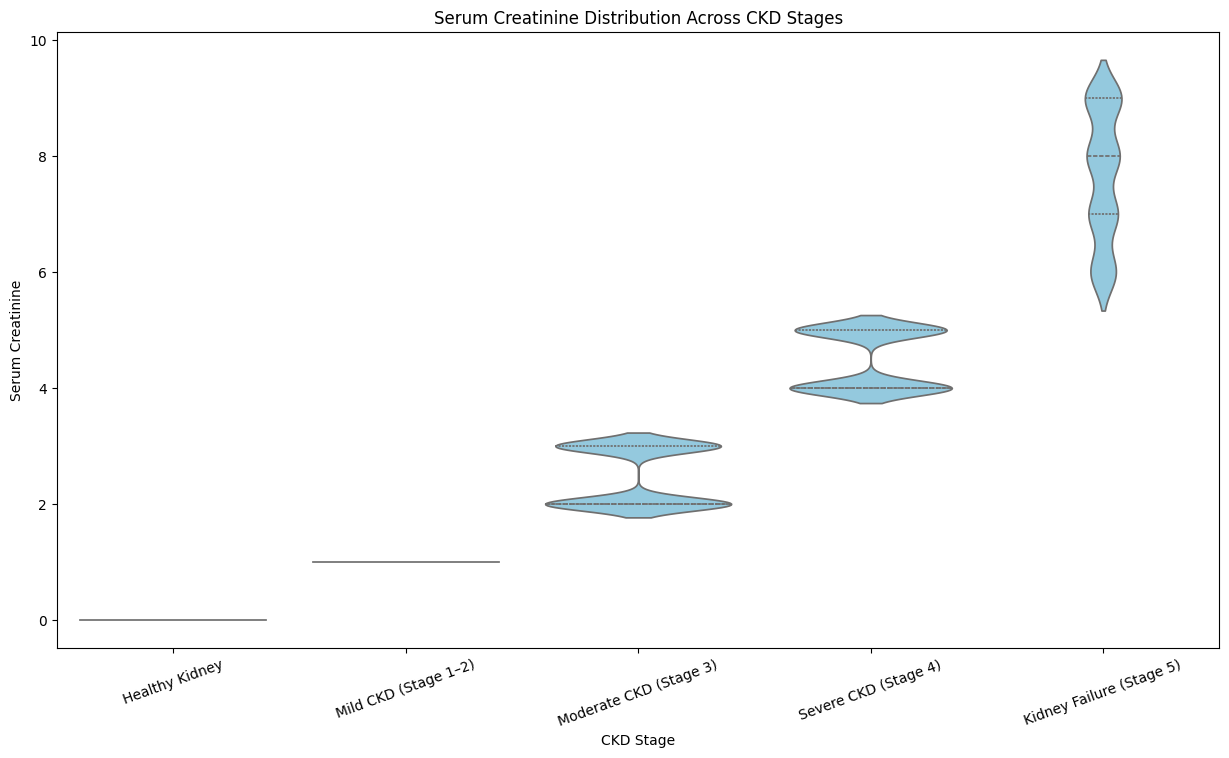

--- Actual Serum_Creatinine Ranges per Stage in Dataset ---
                          Min Creatinine  Max Creatinine  Average Creatinine
Target                                                                      
Healthy Kidney                         0               0                0.00
Mild CKD (Stage 1–2)                   1               1                1.00
Moderate CKD (Stage 3)                 2               3                2.47
Severe CKD (Stage 4)                   4               5                4.48
Kidney Failure (Stage 5)               6               9                7.65


In [12]:
plt.figure(figsize=(15,8))
sns.violinplot(x='Target',y='Serum_Creatinine',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Serum Creatinine")
plt.title("Serum Creatinine Distribution Across CKD Stages")
plt.xticks(rotation=20)

plt.show()


target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

creatinine_ranges = df.groupby('Target')['Serum_Creatinine'].agg(['min', 'max', 'mean']).reindex(target_order)

creatinine_ranges.columns = ['Min Creatinine', 'Max Creatinine', 'Average Creatinine']
print("--- Actual Serum_Creatinine Ranges per Stage in Dataset ---")
print(creatinine_ranges.round(2))

### **Serum Creatinine Distribution Across CKD Stages**
* **Healthy Kidney:** Creatinine is very low (~0), indicating normal kidney function.
* **Mild CKD (Stage 1–2):** Creatinine appears unusually low (~1), showing early kidney dysfunction with considerable variation.
* **Moderate CKD (Stage 3):** Creatinine ranges roughly 2-3, suggesting possible data sparsity or specific patient filtering in this stage.
* **Severe CKD (Stage 4):** Creatinine ranges roughly 4-5, reflecting advanced kidney damage and decreased waste clearance.
* **Kidney Failure (Stage 5):** Creatinine ranges roughly 6-9 with a bimodal distribution, indicating severe impairment and diverse patient conditions.
* **Overall:** Serum creatinine generally increases with CKD severity.

## Q 5} What is the impact of Albumin Creatinine Ratio on Kidney Health?

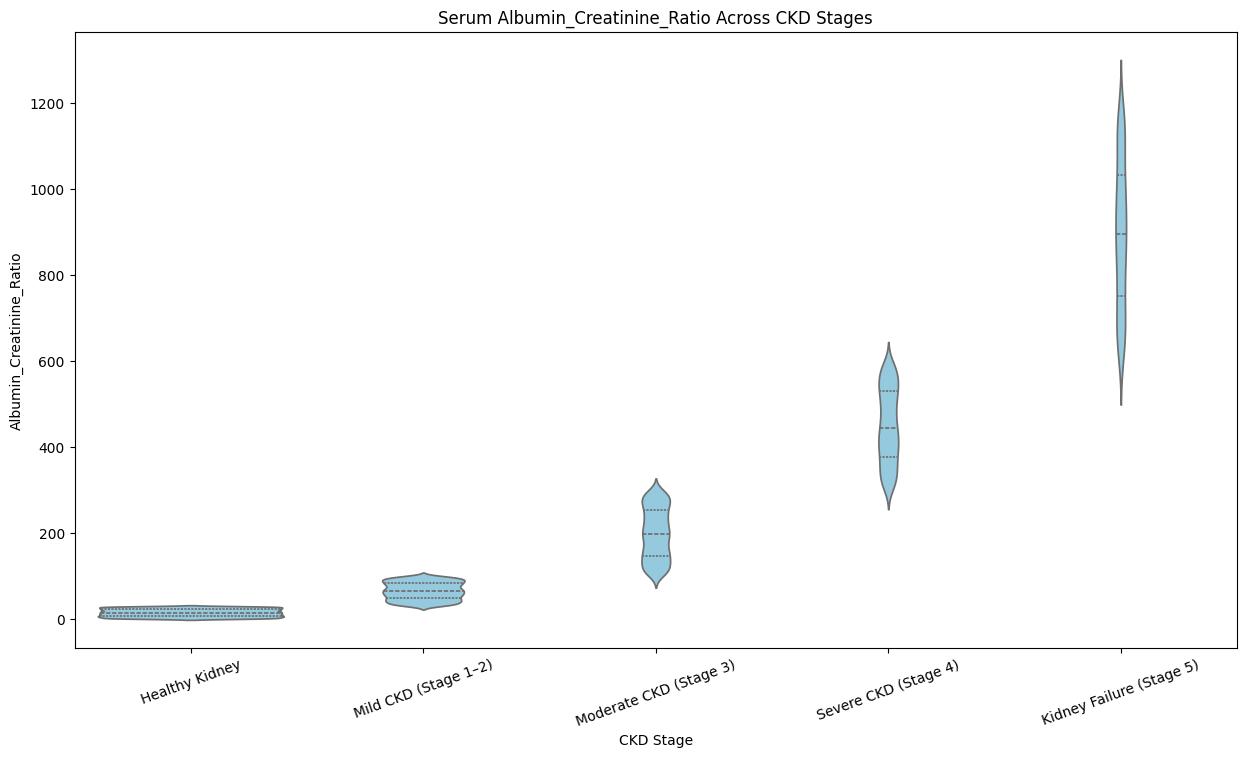

--- Actual Albumin_Creatinine_Ratio (ACR) Ranges per Stage ---
                          Min ACR  Max ACR  Average ACR
Target                                                 
Healthy Kidney                  0       29        14.49
Mild CKD (Stage 1–2)           30       99        64.96
Moderate CKD (Stage 3)        100      299       198.85
Severe CKD (Stage 4)          300      599       450.02
Kidney Failure (Stage 5)      600     1199       895.94


In [13]:
plt.figure(figsize=(15,8))
sns.violinplot(x='Target',y='Albumin_Creatinine_Ratio',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Albumin_Creatinine_Ratio")
plt.title("Serum Albumin_Creatinine_Ratio Across CKD Stages")
plt.xticks(rotation=20)

plt.show()


target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

acr_ranges = df.groupby('Target')['Albumin_Creatinine_Ratio'].agg(['min', 'max', 'mean']).reindex(target_order)

acr_ranges.columns = ['Min ACR', 'Max ACR', 'Average ACR']
print("--- Actual Albumin_Creatinine_Ratio (ACR) Ranges per Stage ---")
print(acr_ranges.round(2))

### **Serum Albumin-Creatinine Ratio (ACR) Distribution Across CKD Stages**
* **Healthy Kidney:** Levels are extremely low 0 - 29, indicating intact glomerular filtration and minimal protein loss.
* **Mild CKD (Stage 1–2):** Levels rise slightly (30–99), marking the onset of microalbuminuria.
* **Moderate CKD (Stage 3):** Significant jump (100–299), reflecting worsening damage to the kidney's filtering units.
* **Severe CKD (Stage 4):** High concentrations (300–599) with increased variability among patients as kidneys struggle.
* **Kidney Failure (Stage 5):** Exponentially high and varied values (600-1199), representing total filtration failure.
* **Overall:** ACR shows a clear exponential upward trend with disease progression, making it a highly sensitive marker for late-stage kidney failure.


## Q 6} What is the impact of Urine Protein on Kidney Health?

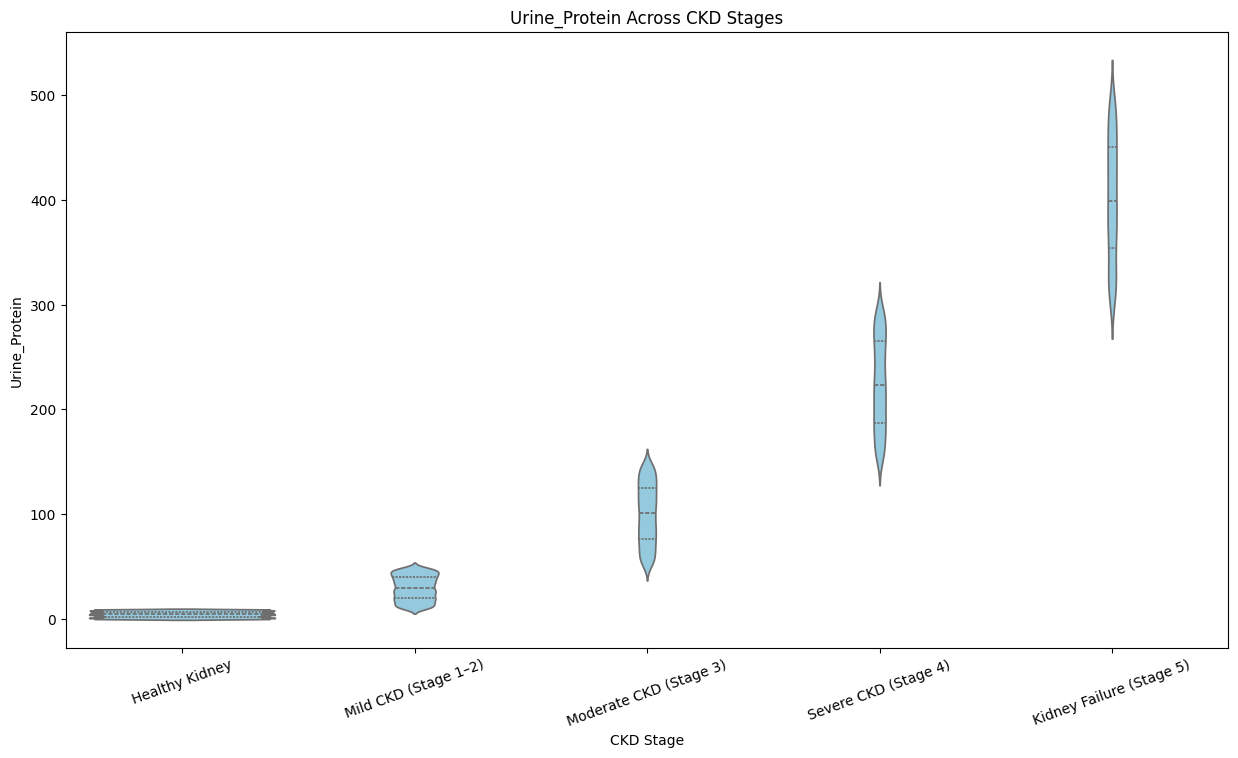

--- Actual Urine_Protein Ranges per Stage ---
                          Min Protein  Max Protein  Average Protein
Target                                                             
Healthy Kidney                      0            9             4.51
Mild CKD (Stage 1–2)               10           49            29.83
Moderate CKD (Stage 3)             50          149           100.49
Severe CKD (Stage 4)              150          299           224.65
Kidney Failure (Stage 5)          302          499           400.89


In [14]:
plt.figure(figsize=(15,8))
sns.violinplot(x='Target',y='Urine_Protein',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Urine_Protein")
plt.title("Urine_Protein Across CKD Stages")
plt.xticks(rotation=20)

plt.show()

target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

protein_ranges = df.groupby('Target')['Urine_Protein'].agg(['min', 'max', 'mean']).reindex(target_order)

protein_ranges.columns = ['Min Protein', 'Max Protein', 'Average Protein']
print("--- Actual Urine_Protein Ranges per Stage ---")
print(protein_ranges.round(2))

### **Urine Protein Distribution Across CKD Stages**
* **Healthy Kidney:** Negligible protein levels (0–9), indicating healthy, non-permeable kidney membranes.
* **Mild CKD (Stage 1–2):** Elevated levels (10–49), marking the clinical transition to proteinuria.
* **Moderate CKD (Stage 3):** Levels reach 50–149, signaling significant metabolic and filtration dysfunction.
* **Severe CKD (Stage 4):** Levels escalate to 150–299 with a notably wider distribution of values.
* **Kidney Failure (Stage 5):** Peak protein levels (302–499), representing massive, unregulated protein leakage into urine.
* **Overall:** Urine protein increases in a predictable stepwise fashion, providing excellent separability for machine learning stage classification.


## Q 7} What is the impact of Urine Albumin on Kidney Health?

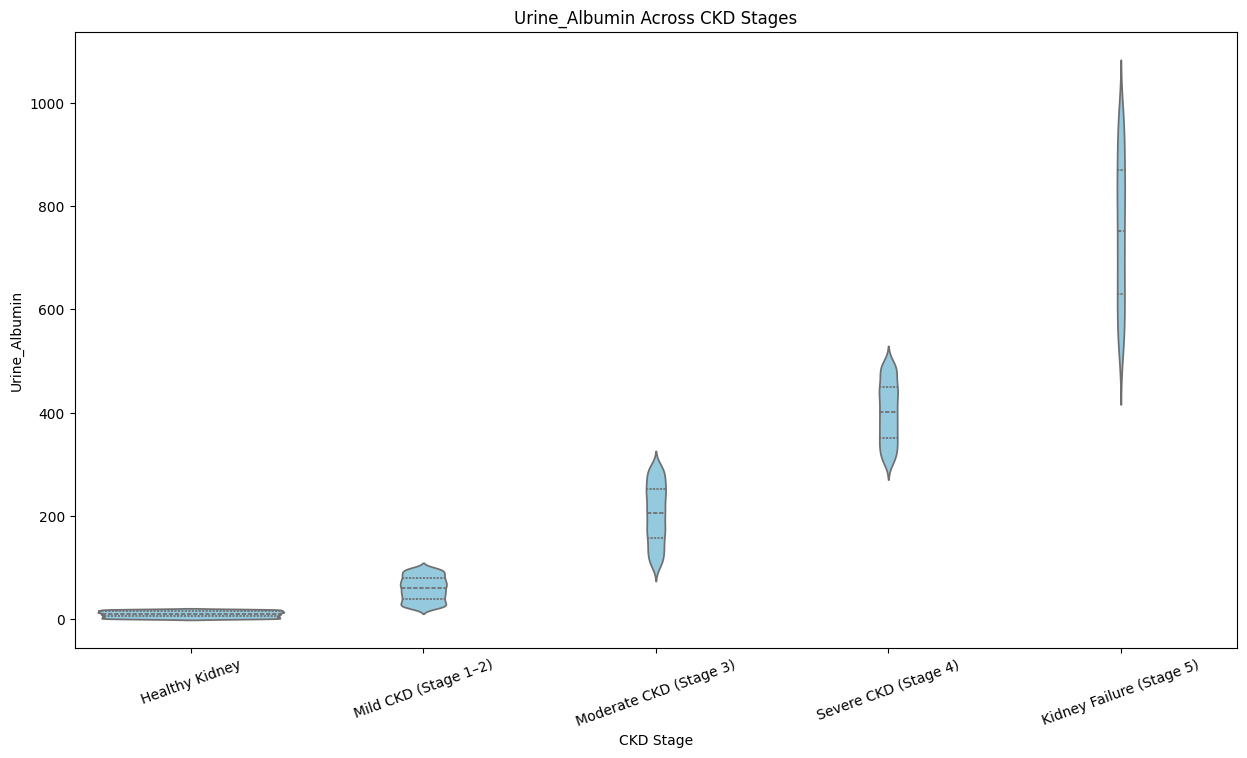

--- Actual Urine_Albumin Ranges per Stage ---
                          Min Urine Albumin  Max Urine Albumin  \
Target                                                           
Healthy Kidney                            0                 19   
Mild CKD (Stage 1–2)                     20                 99   
Moderate CKD (Stage 3)                  100                299   
Severe CKD (Stage 4)                    300                499   
Kidney Failure (Stage 5)                500                999   

                          Average Urine Albumin  
Target                                           
Healthy Kidney                             9.55  
Mild CKD (Stage 1–2)                      59.24  
Moderate CKD (Stage 3)                   203.39  
Severe CKD (Stage 4)                     400.85  
Kidney Failure (Stage 5)                 752.16  


In [15]:
plt.figure(figsize=(15,8))
sns.violinplot(x='Target',y='Urine_Albumin',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Urine_Albumin")
plt.title("Urine_Albumin Across CKD Stages")
plt.xticks(rotation=20)

plt.show()


target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

albumin_ranges = df.groupby('Target')['Urine_Albumin'].agg(['min', 'max', 'mean']).reindex(target_order)

albumin_ranges.columns = ['Min Urine Albumin', 'Max Urine Albumin', 'Average Urine Albumin']
print("--- Actual Urine_Albumin Ranges per Stage ---")
print(albumin_ranges.round(2))

### **Urine Albumin Distribution Across CKD Stages**
* **Healthy Kidney:** Baseline levels (0–19) consistent with healthy filtration.
* **Mild CKD (Stage 1–2):** Modest rise (20–99), reflecting early-stage glomerular leakage.
* **Moderate CKD (Stage 3):** Levels double (100–299), marking progressive breakdown of the kidney’s barrier.
* **Severe CKD (Stage 4):** Values cluster significantly higher (around 300–499), showing advanced damage.
* **Kidney Failure (Stage 5):** Widest and highest distribution (500–999), indicating severe, end-stage filtration integrity loss.
* **Overall:** Urine albumin is a vital diagnostic feature with high predictive value for determining the severity of renal damage.

## Q 8} What is the impact of Blood Urea Nitrogen on Kidney Health?

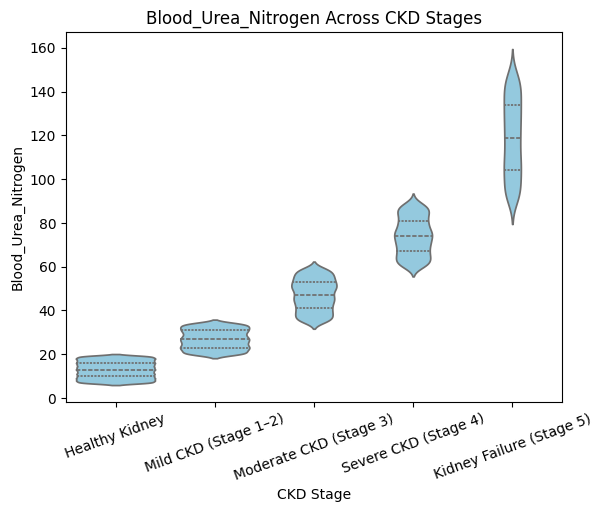

--- Actual Blood_Urea_Nitrogen (BUN) Ranges per Stage ---
                          Min BUN  Max BUN  Average BUN
Target                                                 
Healthy Kidney                  7       19        12.99
Mild CKD (Stage 1–2)           20       34        26.97
Moderate CKD (Stage 3)         35       59        47.16
Severe CKD (Stage 4)           60       89        74.01
Kidney Failure (Stage 5)       90      149       119.03


In [16]:
sns.violinplot(x='Target',y='Blood_Urea_Nitrogen',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Blood_Urea_Nitrogen")
plt.title("Blood_Urea_Nitrogen Across CKD Stages")
plt.xticks(rotation=20)

plt.show()


target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

bun_ranges = df.groupby('Target')['Blood_Urea_Nitrogen'].agg(['min', 'max', 'mean']).reindex(target_order)

bun_ranges.columns = ['Min BUN', 'Max BUN', 'Average BUN']
print("--- Actual Blood_Urea_Nitrogen (BUN) Ranges per Stage ---")
print(bun_ranges.round(2))

### **Blood Urea Nitrogen (BUN) Distribution Across CKD Stages**
* **Healthy Kidney:** Normal range (7–19), representing efficient clearance of nitrogenous waste by healthy kidneys.
* **Mild CKD (Stage 1–2):** Slight accumulation (20–34), indicating a minor reduction in the urea filtration rate.
* **Moderate CKD (Stage 3):** Progressive rise to 35–59 as waste clearance becomes significantly impaired.
* **Severe CKD (Stage 4):** High levels (60–89), reflecting advanced azotemia (buildup of urea in the blood).
* **Kidney Failure (Stage 5):** Highest values (90–149), signaling life-threatening uremia and the potential need for dialysis.
* **Overall:** BUN shows a reliable stepwise increase across all stages, serving as a primary indicator of renal metabolic failure.

## Q 9} What is the impact of Potassium on Kidney Health?

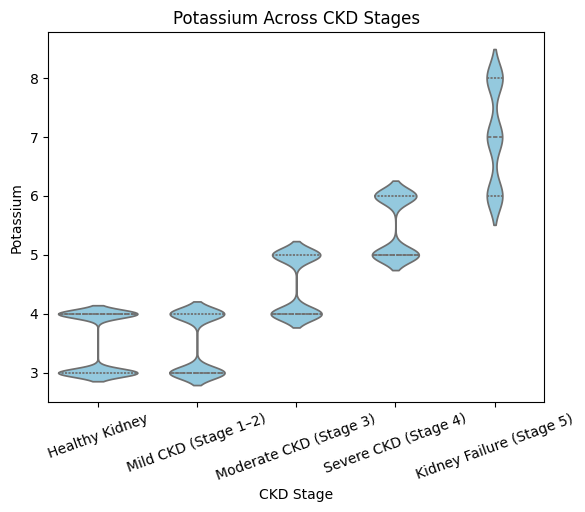

--- Actual Potassium Ranges per Stage (mEq/L) ---
                          Min Potassium  Max Potassium  Average Potassium
Target                                                                   
Healthy Kidney                        3              4               3.50
Mild CKD (Stage 1–2)                  3              4               3.50
Moderate CKD (Stage 3)                4              5               4.49
Severe CKD (Stage 4)                  5              6               5.47
Kidney Failure (Stage 5)              6              8               7.01


In [17]:
sns.violinplot(x='Target',y='Potassium',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Potassium")
plt.title("Potassium Across CKD Stages")
plt.xticks(rotation=20)

plt.show()

target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

potassium_ranges = df.groupby('Target')['Potassium'].agg(['min', 'max', 'mean']).reindex(target_order)

potassium_ranges.columns = ['Min Potassium', 'Max Potassium', 'Average Potassium']
print("--- Actual Potassium Ranges per Stage (mEq/L) ---")
print(potassium_ranges.round(2))

### **Potassium Distribution Across CKD Stages**
* **Healthy Kidney:** Controlled levels (3–4), maintaining the narrow range required for healthy heart and muscle function.
* **Mild CKD (Stage 1–2):** Values remain stable (3–4), as kidneys are still capable of regulating electrolyte balance.
* **Moderate CKD (Stage 3):** Levels shift upward (4–5), showing the onset of excretion issues.
* **Severe CKD (Stage 4):** High levels (5–6), indicating clinical hyperkalemia.
* **Kidney Failure (Stage 5):** Critical, multimodal distribution (6-8), representing severe risk of cardiac arrest and total loss of electrolyte homeostasis.
* **Overall:** Potassium becomes dangerously elevated in late stages, making it a critical safety feature to monitor in advanced CKD cases.


## Q 10} What is the impact of Phosphorus on Kidney Health?

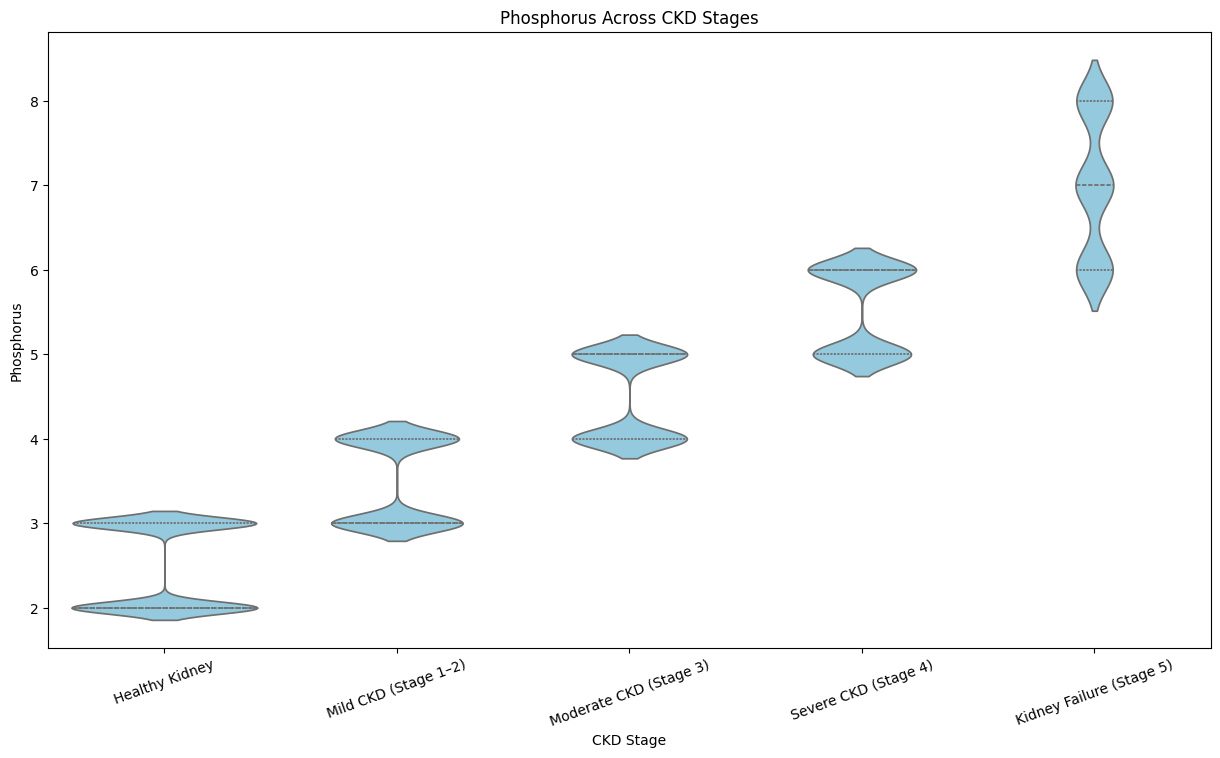

--- Actual Phosphorus Ranges per Stage (mg/dL) ---
                          Min Phosphorus  Max Phosphorus  Average Phosphorus
Target                                                                      
Healthy Kidney                         2               3                2.50
Mild CKD (Stage 1–2)                   3               4                3.49
Moderate CKD (Stage 3)                 4               5                4.50
Severe CKD (Stage 4)                   5               6                5.52
Kidney Failure (Stage 5)               6               8                7.00


In [18]:
plt.figure(figsize=(15,8))
sns.violinplot(x='Target',y='Phosphorus',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Phosphorus")
plt.title("Phosphorus Across CKD Stages")
plt.xticks(rotation=20)

plt.show()

target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

phosphorus_ranges = df.groupby('Target')['Phosphorus'].agg(['min', 'max', 'mean']).reindex(target_order)

phosphorus_ranges.columns = ['Min Phosphorus', 'Max Phosphorus', 'Average Phosphorus']
print("--- Actual Phosphorus Ranges per Stage (mg/dL) ---")
print(phosphorus_ranges.round(2))

### **Phosphorus Distribution Across CKD Stages**
* **Healthy Kidney:** Normal baseline (2–3), showing effective phosphorus excretion.
* **Mild CKD (Stage 1–2):** Slight rise (3–4), reflecting early phosphorus retention as kidney efficiency drops.
* **Moderate CKD (Stage 3):** Levels reach 4–5 with distinct multimodal peaks, suggesting dietary or medical management differences.
* **Severe CKD (Stage 4):** Further elevation (5–6), highlighting worsening mineral metabolism.
* **Kidney Failure (Stage 5):** Highest values (6-8), characteristic of severe bone-mineral disease common in end-stage renal failure.
* **Overall:** Phosphorus levels show clear stepwise increases, highlighting the progressive loss of mineral homeostasis as CKD advances.


## Q 11} What is the impact of Hemoglobin on Kidney Health?

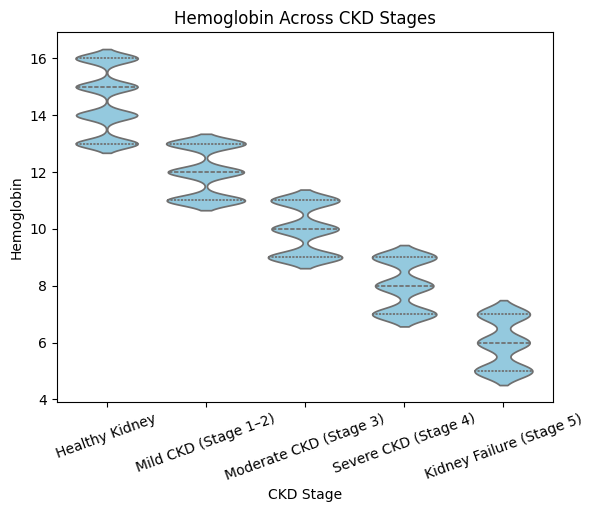

--- Actual Hemoglobin Ranges per Stage (g/dL) ---
                          Min Hemoglobin  Max Hemoglobin  Average Hemoglobin
Target                                                                      
Healthy Kidney                        13              16               14.50
Mild CKD (Stage 1–2)                  11              13               12.00
Moderate CKD (Stage 3)                 9              11                9.97
Severe CKD (Stage 4)                   7               9                8.00
Kidney Failure (Stage 5)               5               7                5.97


In [19]:
sns.violinplot(x='Target',y='Hemoglobin',data=df,inner='quartile',color='skyblue',order=["Healthy Kidney","Mild CKD (Stage 1–2)","Moderate CKD (Stage 3)","Severe CKD (Stage 4)","Kidney Failure (Stage 5)"])
plt.xlabel("CKD Stage")
plt.ylabel("Hemoglobin")
plt.title("Hemoglobin Across CKD Stages")
plt.xticks(rotation=20)

plt.show()


target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

hemoglobin_ranges = df.groupby('Target')['Hemoglobin'].agg(['min', 'max', 'mean']).reindex(target_order)

hemoglobin_ranges.columns = ['Min Hemoglobin', 'Max Hemoglobin', 'Average Hemoglobin']
print("--- Actual Hemoglobin Ranges per Stage (g/dL) ---")
print(hemoglobin_ranges.round(2))

### **Hemoglobin Distribution Across CKD Stages**
* **Healthy Kidney:** High, normal levels (13–16 g/dL), indicating healthy red blood cell production.
* **Mild CKD (Stage 1–2):** Levels begin to drop (11–13 g/dL), signaling the clinical onset of renal anemia.
* **Moderate CKD (Stage 3):** Significant decline to 9–11 g/dL as erythropoietin (EPO) production fails.
* **Severe CKD (Stage 4):** Values cluster much lower (7–9 g/dL), reflecting chronic and severe anemia.
* **Kidney Failure (Stage 5):** Extremely low and varied (5–7 g/dL), often requiring EPO therapy or blood transfusions.
* **Overall:** Hemoglobin shows a strong negative correlation with CKD stages, making it a primary clinical marker for managing CKD-related complications.

# **Multivariate Analysis**

## Checking the correlation among all features and selecting the most correlated features in the dataset.

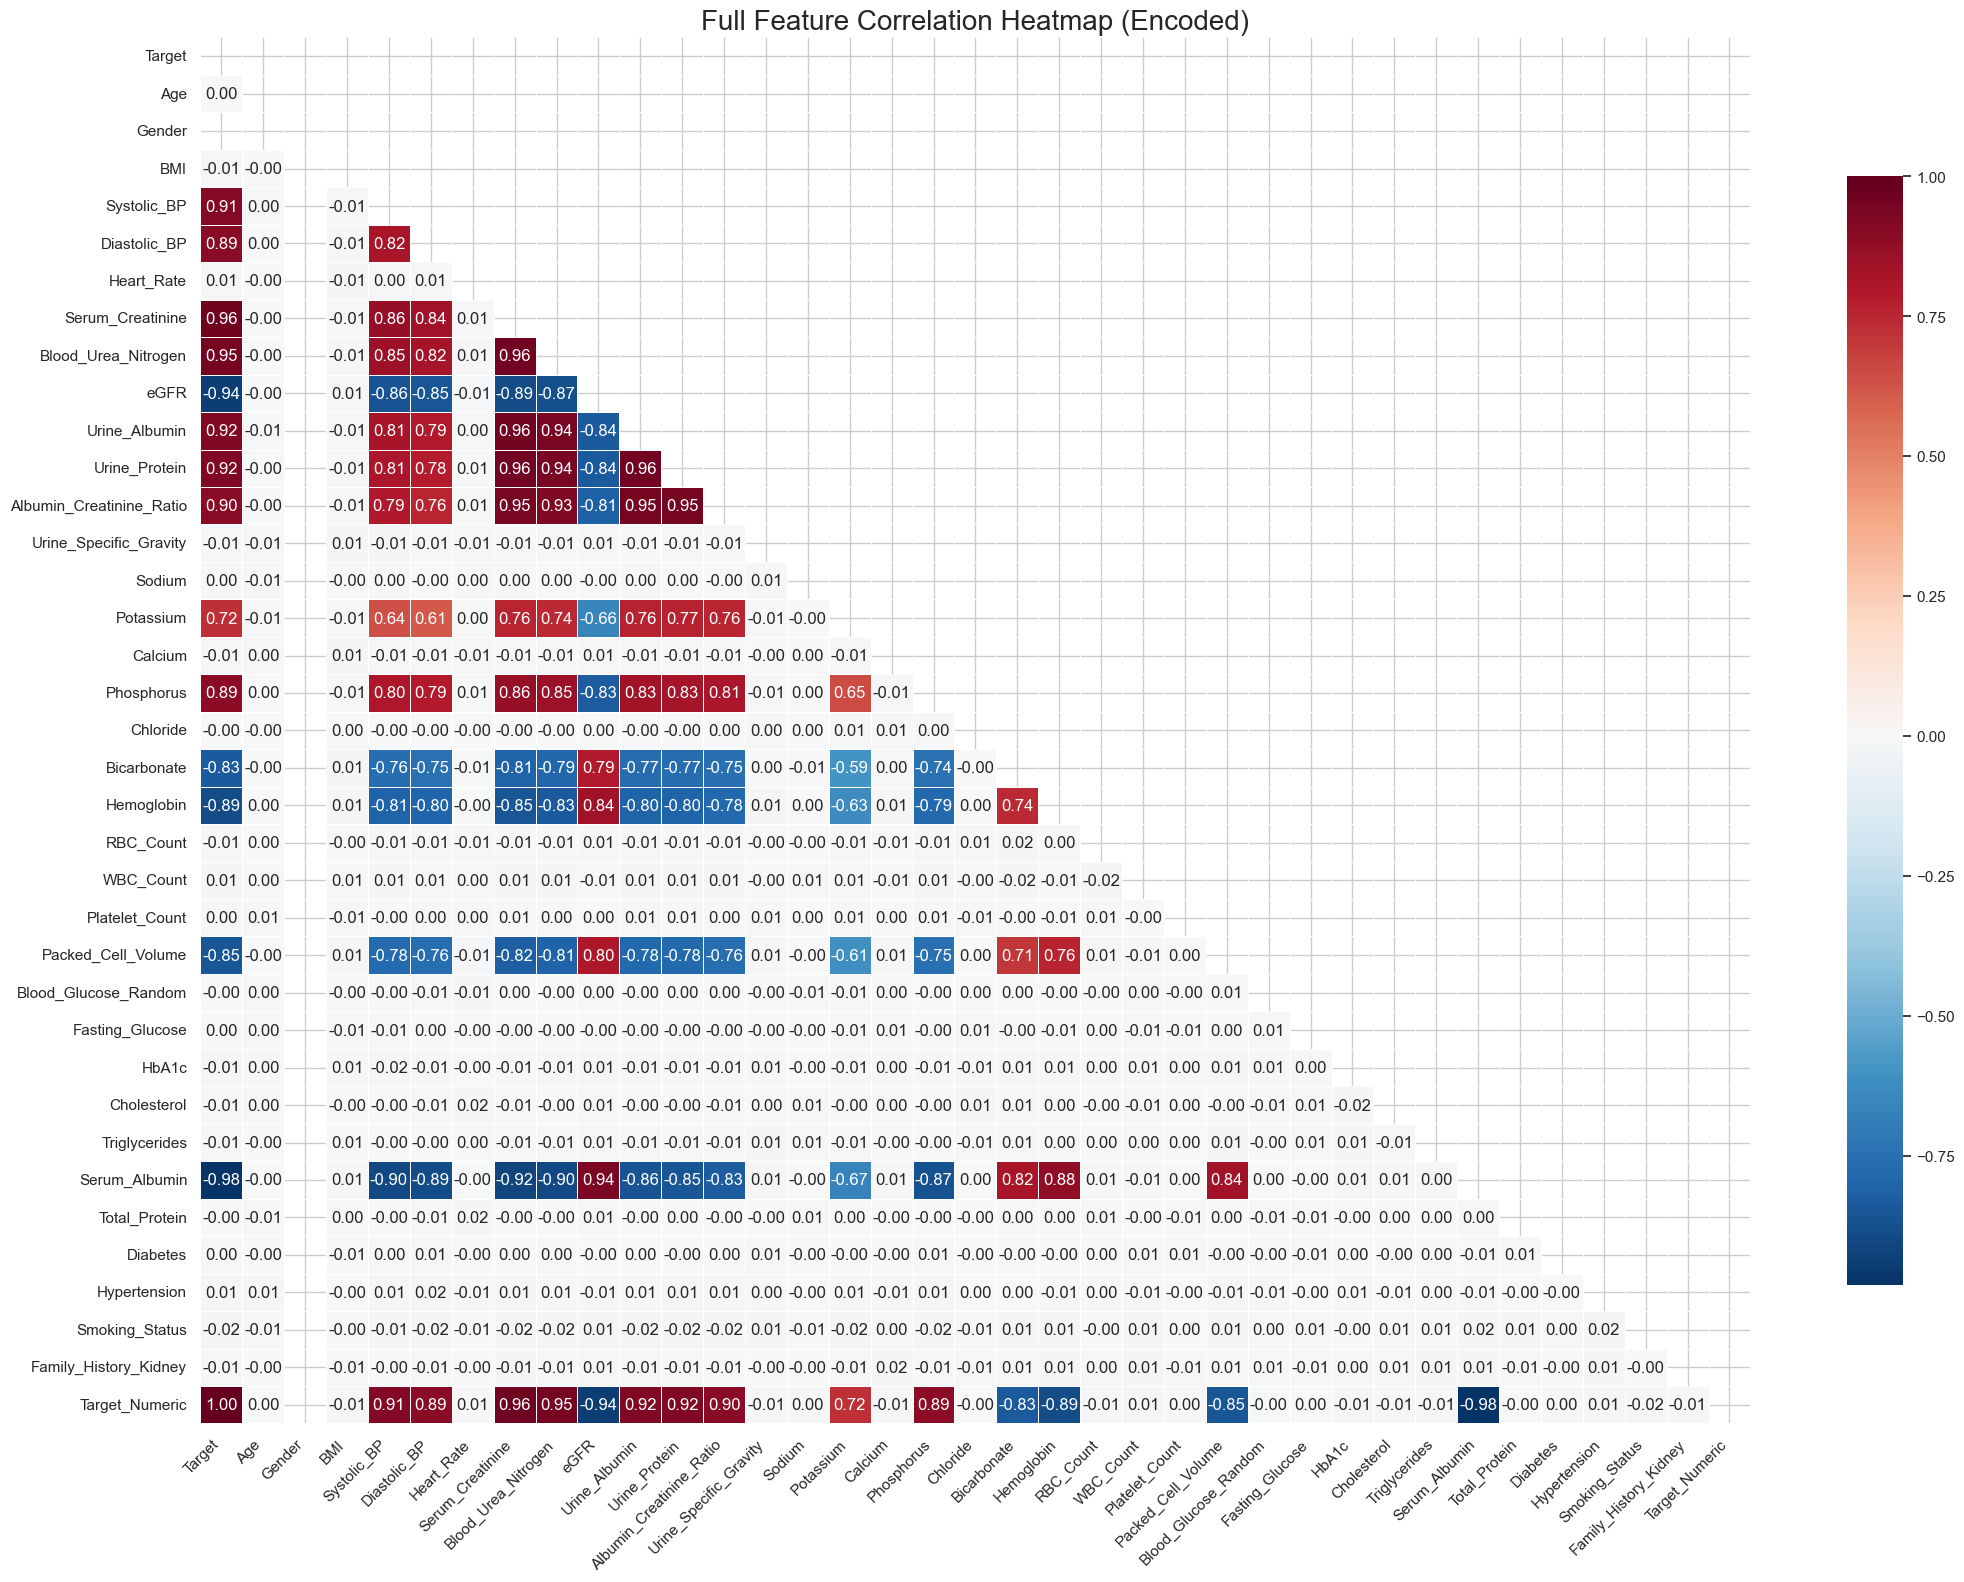

In [30]:
df_encoded = df.copy()

target_map = {
    'Healthy Kidney': 0, 
    'Mild CKD (Stage 1–2)': 1, 
    'Moderate CKD (Stage 3)': 2, 
    'Severe CKD (Stage 4)': 3, 
    'Kidney Failure (Stage 5)': 4
}
df_encoded['Target'] = df_encoded['Target'].map(target_map)

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['Diabetes', 'Hypertension', 'Family_History_Kidney', 'Gender']:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(binary_map)

if 'Smoking_Status' in df_encoded.columns:
    df_encoded['Smoking_Status'] = pd.factorize(df_encoded['Smoking_Status'])[0]

df_numeric = df_encoded.select_dtypes(include=[np.number])

corr_matrix = df_numeric.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(25, 18))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,         
    fmt=".2f",            
    cmap='RdBu_r',        
    center=0, 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Full Feature Correlation Heatmap (Encoded)', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.show()

### The heatmap shows that only 14 columns have significant correlation among them.
- Values near 0 (white blocks) indicate weak correlation or no correlation.
- Values near +1 (red blocks) indicate strong positive correlation.
- Values near −1 (blue blocks) indicate strong negative correlation.

### The heatmap shows strong correlations among these 14 columns.

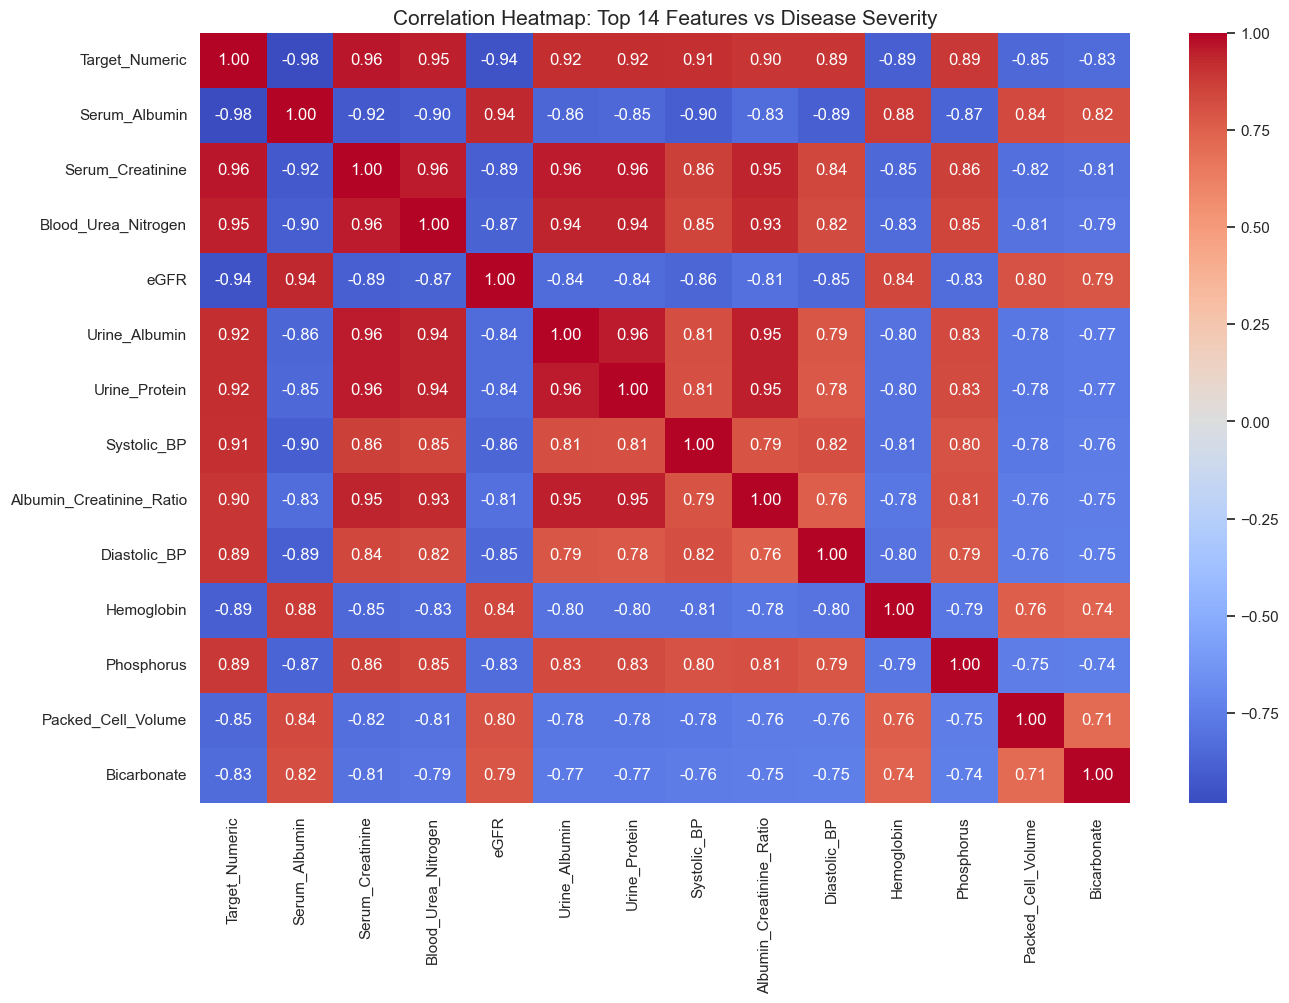

In [31]:
target_order = [
    'Healthy Kidney', 
    'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 
    'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)



plt.figure(figsize=(15, 10))
target_mapping = {val: i for i, val in enumerate(target_order)}
df['Target_Numeric'] = df['Target'].map(target_mapping)
top_corr_cols = df.select_dtypes(include=[np.number]).corr()['Target_Numeric'].abs().sort_values(ascending=False).head(14).index
sns.heatmap(df[top_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Top 14 Features vs Disease Severity', fontsize=15)
plt.show()



## Highly correlated features were identified.
### The following features show strong correlation in the dataset and are important for CKD analysis:
- Serum_Albumin
- Serum_Creatinine
- Blood_Urea_Nitrogen
- eGFR
- Urine_Albumin
- Urine_Protein
- Systolic_BP
- Albumin_Creatinine_Ratio
- Diastolic_BP
- Hemoglobin
- Phosphorus
- Packed_Cell_Volume
- Bicarbonate

# *Comparing highly correlated features of patients with age >30 and <30 to analyze the impact of age on CKD*

## Although CKD typically occurs after the age of 30, we aim to identify cases where individuals below 30 are affected in order to find highly correlated features within the below-30 age group.

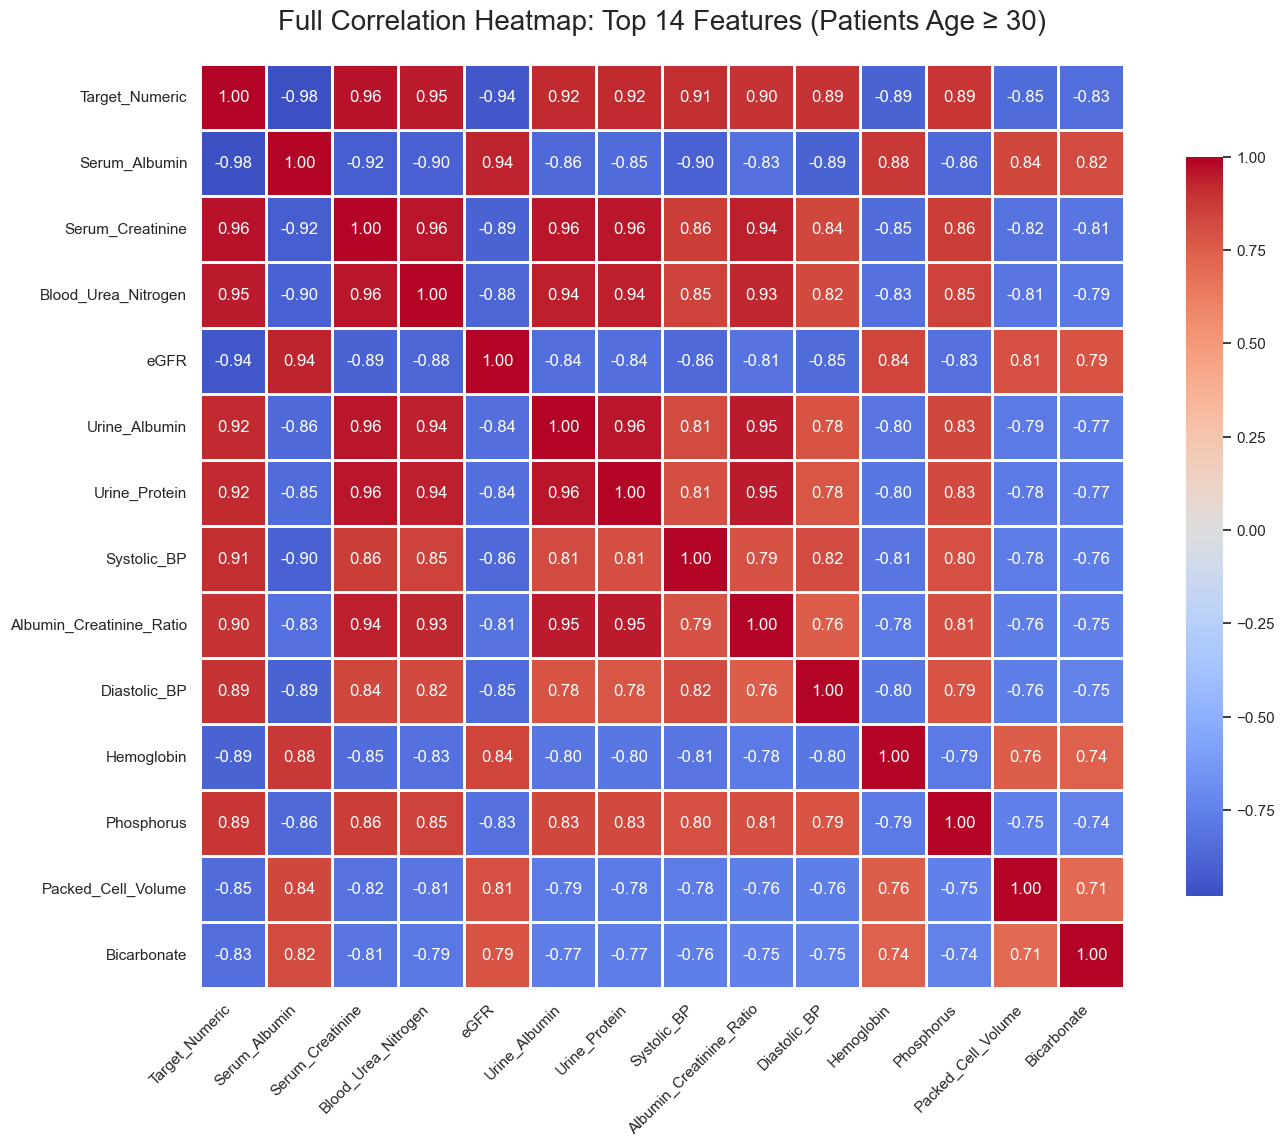

--- Statistics for 17729 patients (Age >= 30) ---

Strongest Positive Drivers (Increase as Stage Increases):
Serum_Creatinine       0.964818
Blood_Urea_Nitrogen    0.947286
Urine_Albumin          0.920970
Urine_Protein          0.918105
Systolic_BP            0.907408
Name: Target_Numeric, dtype: float64

Strongest Negative Drivers (Decrease as Stage Increases):
Serum_Albumin        -0.980499
eGFR                 -0.944451
Hemoglobin           -0.889041
Packed_Cell_Volume   -0.852448
Bicarbonate          -0.833909
Name: Target_Numeric, dtype: float64


In [32]:
df_old = df[df['Age'] >= 30].copy()

target_order = [
    'Healthy Kidney', 'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]
target_map = {val: i for i, val in enumerate(target_order)}
df_old['Target_Numeric'] = df_old['Target'].map(target_map)

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['Diabetes', 'Hypertension', 'Gender', 'Family_History_Kidney']:
    if col in df_old.columns:
        df_old[col] = df_old[col].map(binary_map)

full_corr_matrix_old = df_old.select_dtypes(include=[np.number]).corr()

top_14_features_old = full_corr_matrix_old['Target_Numeric'].abs().sort_values(ascending=False).head(14).index
top_corr_subset_old = df_old[top_14_features_old].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    top_corr_subset_old, 
    annot=True,            
    fmt=".2f",             
    cmap='coolwarm',       
    center=0,              
    linewidths=1,          
    square=True,           
    cbar_kws={"shrink": .8}
)

plt.title('Full Correlation Heatmap: Top 14 Features (Patients Age ≥ 30)', fontsize=20, pad=25)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.show()

print(f"--- Statistics for {len(df_old)} patients (Age >= 30) ---")
print("\nStrongest Positive Drivers (Increase as Stage Increases):")
print(full_corr_matrix_old['Target_Numeric'].sort_values(ascending=False).iloc[1:6])

print("\nStrongest Negative Drivers (Decrease as Stage Increases):")
print(full_corr_matrix_old['Target_Numeric'].sort_values(ascending=True).iloc[:5])

## Highly Correlated 10 Features Identified
### The following features show strong correlation in the dataset and are important for CKD analysis for the age group above 30:
- Serum_Creatinine
- Blood_Urea_Nitrogen
- Urine_Albumin
- Urine_Protein
- Systolic_BP
- Serum_Albumin
- eGFR
- Hemoglobin
- Packed_Cell_Volume
- Bicarbonate

## Although CKD typically occurs after the age of 30, we aim to identify cases where individuals below 30 are affected in order to find highly correlated features within the below-30 age group.

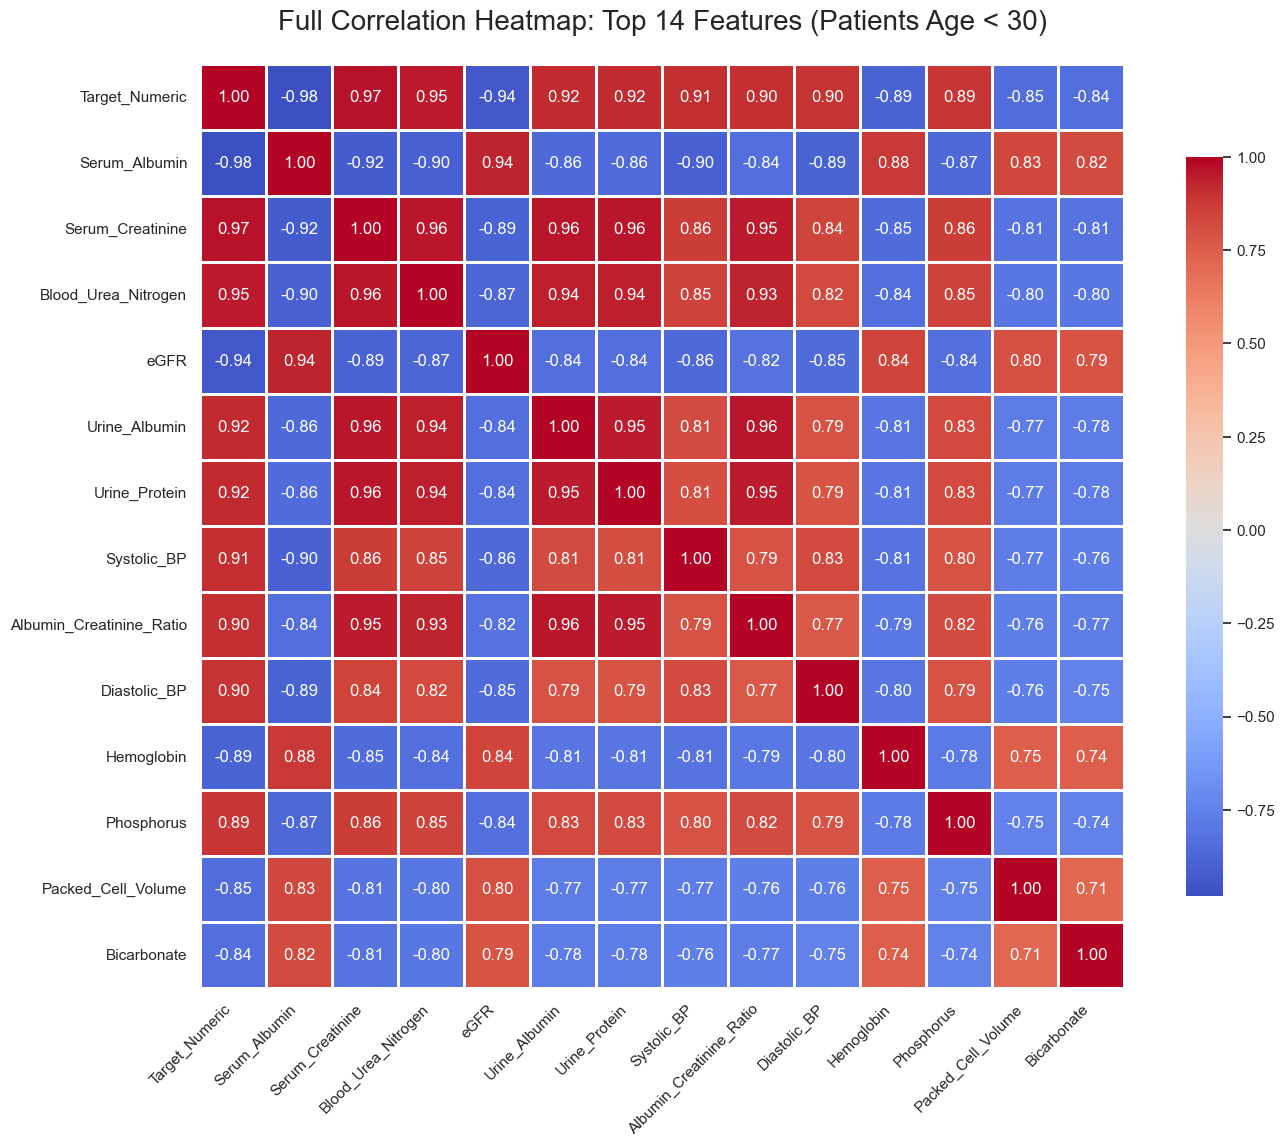

In [33]:
df_young = df[df['Age'] < 30].copy()

target_order = [
    'Healthy Kidney', 'Mild CKD (Stage 1–2)', 
    'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 
    'Kidney Failure (Stage 5)'
]
target_map = {val: i for i, val in enumerate(target_order)}
df_young['Target_Numeric'] = df_young['Target'].map(target_map)

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['Diabetes', 'Hypertension', 'Gender', 'Family_History_Kidney']:
    if col in df_young.columns:
        df_young[col] = df_young[col].map(binary_map)

full_corr_matrix = df_young.select_dtypes(include=[np.number]).corr()

top_15_features = full_corr_matrix['Target_Numeric'].abs().sort_values(ascending=False).head(14).index
top_corr_subset = df_young[top_15_features].corr()
plt.figure(figsize=(16, 12))

sns.heatmap(
    top_corr_subset, 
    annot=True,           
    fmt=".2f",            
    cmap='coolwarm',      
    center=0,             
    linewidths=1,        
    square=True,           
    cbar_kws={"shrink": .8}
)

plt.title('Full Correlation Heatmap: Top 14 Features (Patients Age < 30)', fontsize=20, pad=25)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.show()


In [34]:
print("Strongest Positive Drivers (Increase as Stage Increases):")
print(full_corr_matrix['Target_Numeric'].sort_values(ascending=False).iloc[1:6])

print("\nStrongest Negative Drivers (Decrease as Stage Increases):")
print(full_corr_matrix['Target_Numeric'].sort_values(ascending=True).iloc[:5])

Strongest Positive Drivers (Increase as Stage Increases):
Serum_Creatinine       0.965524
Blood_Urea_Nitrogen    0.946405
Urine_Albumin          0.921918
Urine_Protein          0.920876
Systolic_BP            0.906927
Name: Target_Numeric, dtype: float64

Strongest Negative Drivers (Decrease as Stage Increases):
Serum_Albumin        -0.981304
eGFR                 -0.943488
Hemoglobin           -0.891427
Packed_Cell_Volume   -0.846857
Bicarbonate          -0.837962
Name: Target_Numeric, dtype: float64


## Highly correlated 10 features were identified.
### The following features show strong correlation in the dataset and are important for CKD analysis for the age group below 30:
- Serum_Creatinine
- Blood_Urea_Nitrogen
- Urine_Albumin
- Urine_Protein
- Systolic_BP
- Serum_Albumin
- eGFR
- Hemoglobin
- Packed_Cell_Volume
- Bicarbonate

### Comparing highly correlated features of patients with age >30 and <30 to analyze the impact of age on CKD.
In both age groups (<30 and >30), the same highly correlated features were identified: 
- Serum Creatinine
- Blood Urea Nitrogen
- Urine Albumin
- Urine Protein
- Systolic BP
- Serum Albumin
- eGFR
- Hemoglobin
- Packed Cell Volume
- Bicarbonate

# Overall Summary 
- CKD can occur at any age if key medical parameters (Serum Creatinine, Blood Urea Nitrogen, Urine Albumin, Urine Protein, Systolic BP, Serum Albumin, eGFR, Hemoglobin, Packed Cell Volume, and Bicarbonate) fall within the ranges defining a specific CKD stage.

# *The Ambiguity Zone Analysis.*

**"The Diagnostic Blind Spot: Addressing Clinical Ambiguity in Chronic Kidney Disease (CKD) Detection"**

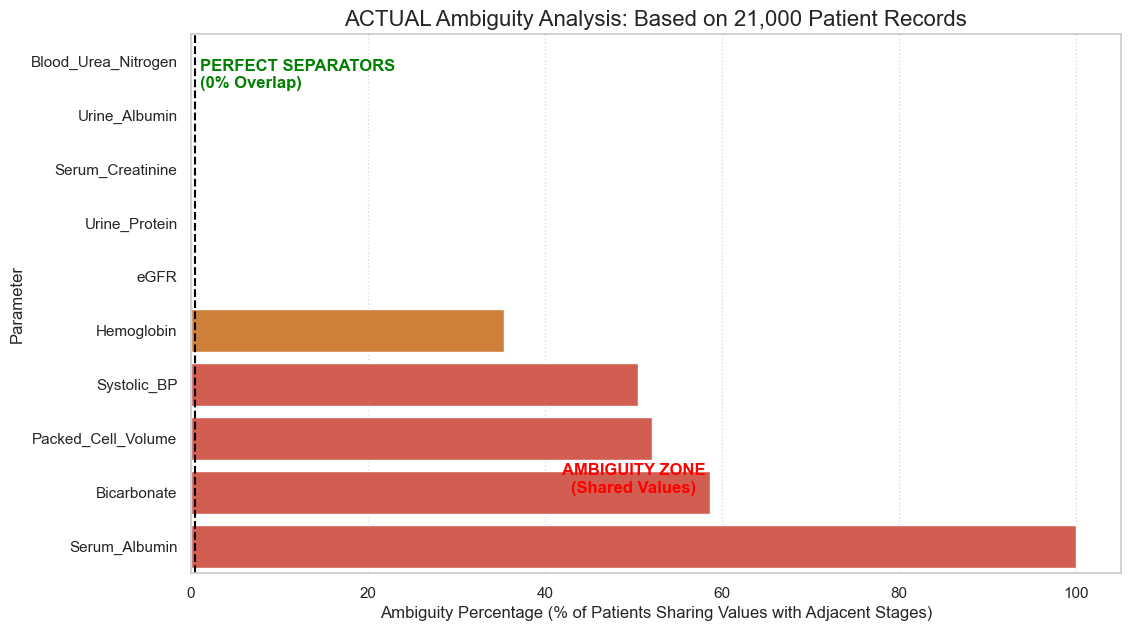

In [35]:
cols_to_check = [
    'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'Urine_Albumin', 
    'Urine_Protein', 'Systolic_BP', 'Serum_Albumin', 'eGFR', 
    'Hemoglobin', 'Packed_Cell_Volume', 'Bicarbonate'
]

transition_pairs = [
    ('Healthy Kidney', 'Mild CKD (Stage 1–2)'),
    ('Mild CKD (Stage 1–2)', 'Moderate CKD (Stage 3)'),
    ('Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)'),
    ('Severe CKD (Stage 4)', 'Kidney Failure (Stage 5)')
]

df_rounded = df.copy()
for col in cols_to_check:
    df_rounded[col] = df_rounded[col].round(2)

all_results = []
for col in cols_to_check:
    for stage_a, stage_b in transition_pairs:
        set_a = set(df_rounded[df_rounded['Target'] == stage_a][col])
        set_b = set(df_rounded[df_rounded['Target'] == stage_b][col])
        overlapping_values = sorted(list(set_a.intersection(set_b)))
        
        if overlapping_values:
            count_a = df_rounded[(df_rounded['Target'] == stage_a) & (df_rounded[col].isin(overlapping_values))].shape[0]
            total_a = df_rounded[df_rounded['Target'] == stage_a].shape[0]
            pct_overlap_a = (count_a / total_a) * 100
            all_results.append({'Parameter': col, 'Pct_Ambiguous': pct_overlap_a})

overlap_matrix = pd.DataFrame(all_results)

dynamic_amb_df = overlap_matrix.groupby('Parameter')['Pct_Ambiguous'].max().reset_index()

found_markers = dynamic_amb_df['Parameter'].unique()
perfect_markers = [m for m in cols_to_check if m not in found_markers]
perfect_df = pd.DataFrame({'Parameter': perfect_markers, 'Pct_Ambiguous': [0.0] * len(perfect_markers)})

final_amb_df = pd.concat([dynamic_amb_df, perfect_df]).sort_values(by='Pct_Ambiguous')

plt.figure(figsize=(12, 7))

colors = ['#2ecc71' if x == 0 else '#e67e22' if x < 40 else '#e74c3c' for x in final_amb_df['Pct_Ambiguous']]

sns.barplot(
    x='Pct_Ambiguous', 
    y='Parameter', 
    data=final_amb_df, 
    hue='Parameter', 
    palette=colors, 
    legend=False
)

plt.axvline(x=0.5, color='black', linestyle='--')
plt.text(1, 0.5, 'PERFECT SEPARATORS\n(0% Overlap)', color='green', fontweight='bold')
plt.text(max(final_amb_df['Pct_Ambiguous'])/2, len(final_amb_df)-2, 'AMBIGUITY ZONE\n(Shared Values)', color='red', fontweight='bold', ha='center')

plt.title('ACTUAL Ambiguity Analysis: Based on 21,000 Patient Records', fontsize=16)
plt.xlabel('Ambiguity Percentage (% of Patients Sharing Values with Adjacent Stages)')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()

### The Summary of Plot 

*   **The Black Dotted Line (0%):** Represents **Diagnostic Perfection**. Any marker sitting on this line has zero overlap between stages, meaning it is a 100% reliable "Truth-Teller."
*   **Zero-Bar Markers (eGFR, Creatinine, Urine Albumin):** These are **Perfect Separators**. In this dataset, they never "lie." If the eGFR moves across a threshold, the stage changes instantly.
*   **The Length of the Bar:** Represents **The Confusion Factor**. The longer the bar, the more "Shared Values" exist between different stages of the disease.
*   **The Brown Bar (Hemoglobin - 33.5%):** Shows that **1 in 3 patients** has a Hemoglobin level that could belong to two different stages. It is a "Lagging Indicator"—it stays healthy while the kidney is already failing.
*   **The Red Bars (PCV, Systolic BP - >50%):** These are **Blurry Markers**. With over 50% ambiguity, these markers are "Coin Flips." Half of the patients in Stage 4 look identical to patients in Stage 5 when only looking at these values.
*   **The Color Logic:** Moves from **Green** (Certainty) to **Red** (Ambiguity), visually proving which markers a doctor should trust for diagnosis and which are merely "secondary symptoms."


## Section: Diagnostic Gold Standards (Zero-Ambiguity Features)

### **1. Executive Summary**
After performing a Global Ambiguity Analysis across all 31 clinical markers, we have identified a "High-Certainty Cluster." Unlike systemic markers (e.g., Hemoglobin or Blood Pressure) which exhibit significant transitional overlap, these five features provide **absolute separation** between CKD stages in our dataset.

### **2. The "Perfect Separators"**
These features are identified as the most critical indicators for CKD analysis because they do not fall under the **Ambiguity Zone (0% Overlap)**:

1.  **eGFR (Estimated Glomerular Filtration Rate):** The primary mathematical measure of renal clearance.
2.  **Serum_Creatinine:** The most reliable blood-based metabolic waste marker.
3.  **Urine_Albumin:** The earliest indicator of physical damage to the kidney's filtration barriers.
4.  **Urine_Protein:** A high-certainty marker for advanced glomerular leakage.
5.  **Blood_Urea_Nitrogen (BUN):** A precise indicator of nitrogenous waste accumulation.

### **3. Clinical Implications**
While other markers are useful for monitoring complications (like Anemia or Hypertension), these **Final 5 Features** should be the primary inputs for any predictive Machine Learning models. They offer the highest "Signal-to-Noise" ratio and ensure that patients are not misclassified due to transitional ambiguity.


# **Conclusion: Diagnostic Hierarchy**

*   **Gold Standard (0% Ambiguity):** BUN, Urine Albumin, Creatinine, Protein, and eGFR are **Perfect Separators**. They provide 100% reliable stage identification.
*   **The Ambiguity Zone (35-60%):** Hemoglobin, BP, and PCV overlap significantly across stages. This explains the **"Silent Killer"** effect, where sick patients appear healthy on standard blood panels.
*   **The Zero-Power Marker (100%):** Serum Albumin is entirely ambiguous between adjacent stages and cannot be used for staging.
*   **Outcome:** Accurate CKD detection must prioritize **Renal Anchors** (eGFR/Urine) over **Systemic Markers** (BP/Blood counts) due to massive transitional overlap.